In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import math
from astropy.visualization.hist import hist
from sklearn.neighbors import KernelDensity

(array([0.01327548, 0.09292835, 0.1194793 , 0.13275478, 0.23895861,
        0.38498887, 0.39826434, 0.47791721, 0.62394747, 0.79652869,
        0.69032486, 0.67704939, 0.8496306 , 0.82307965, 1.04876278,
        1.20806851, 1.34082329, 1.40720069, 1.4603026 , 1.5797819 ,
        1.77891407, 1.8851179 , 2.16390294, 2.44268798, 2.23028033,
        2.24355581, 2.90732972, 3.09318641, 3.31886954, 4.0755718 ,
        4.04902084, 4.56676449, 5.40311961, 5.16416101, 6.63773908,
        7.63339995, 8.44320411, 9.78402741, 9.29283472, 9.01404967,
        7.5404716 , 6.02706709, 3.96936797, 2.36303511, 1.38064973,
        0.63722295, 0.23895861, 0.09292835, 0.01327548]),
 array([0.6974937 , 0.70502639, 0.71255907, 0.72009176, 0.72762445,
        0.73515713, 0.74268982, 0.7502225 , 0.75775519, 0.76528787,
        0.77282056, 0.78035324, 0.78788593, 0.79541861, 0.8029513 ,
        0.81048398, 0.81801667, 0.82554935, 0.83308204, 0.84061473,
        0.84814741, 0.8556801 , 0.86321278, 0.87074547, 0.

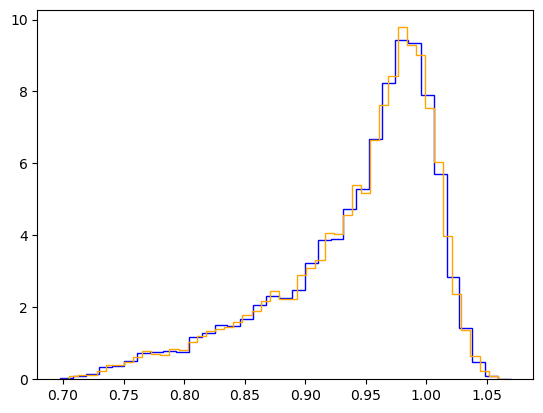

In [2]:
N = 10000

spin = np.random.uniform(0, 1, N)
distG = scipy.stats.norm(loc=1, scale=0.02)
mass = distG.rvs(N)

M_irr = []
f = []

i = 0
for i in range(0, N): 
    M_irr.append(mass[i]*math.sqrt((1+math.sqrt(1-spin[i]**2))/2))
    f.append(math.sqrt((1+math.sqrt(1-spin[i]**2))/2))

M_irr = np.array(M_irr)
f = np.array(f)
    
hist(M_irr, bins="scott", histtype="step", density=True, color='blue')
hist(M_irr, bins="freedman", histtype="step", density=True, color='orange')

(array([0.01327548, 0.09292835, 0.1194793 , 0.13275478, 0.23895861,
        0.38498887, 0.39826434, 0.47791721, 0.62394747, 0.79652869,
        0.69032486, 0.67704939, 0.8496306 , 0.82307965, 1.04876278,
        1.20806851, 1.34082329, 1.40720069, 1.4603026 , 1.5797819 ,
        1.77891407, 1.8851179 , 2.16390294, 2.44268798, 2.23028033,
        2.24355581, 2.90732972, 3.09318641, 3.31886954, 4.0755718 ,
        4.04902084, 4.56676449, 5.40311961, 5.16416101, 6.63773908,
        7.63339995, 8.44320411, 9.78402741, 9.29283472, 9.01404967,
        7.5404716 , 6.02706709, 3.96936797, 2.36303511, 1.38064973,
        0.63722295, 0.23895861, 0.09292835, 0.01327548]),
 array([0.6974937 , 0.70502639, 0.71255907, 0.72009176, 0.72762445,
        0.73515713, 0.74268982, 0.7502225 , 0.75775519, 0.76528787,
        0.77282056, 0.78035324, 0.78788593, 0.79541861, 0.8029513 ,
        0.81048398, 0.81801667, 0.82554935, 0.83308204, 0.84061473,
        0.84814741, 0.8556801 , 0.86321278, 0.87074547, 0.

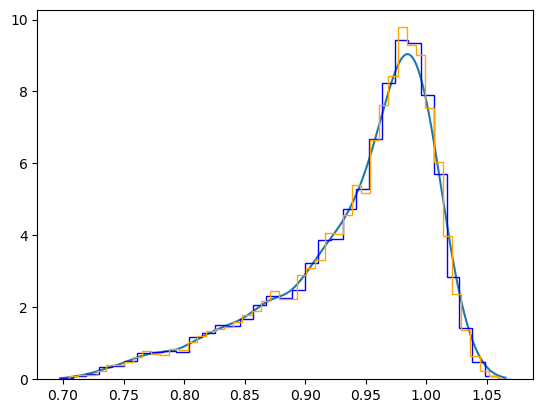

In [3]:
x = np.linspace(min(M_irr), max(M_irr), N)

def kde_sklearn(data, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x[:, np.newaxis])

    return np.exp(log_pdf)

PDFtophat = kde_sklearn(M_irr, bandwidth=0.01, kernel="gaussian")
plt.plot(x, PDFtophat)
hist(M_irr, bins="scott", histtype="step", density=True, color='blue')
hist(M_irr, bins="freedman", histtype="step", density=True, color='orange')

(array([ 0.10537318,  0.15805976,  0.223918  ,  0.27660459,  0.31611953,
         0.50052259,  0.65858235,  0.6454107 ,  0.671754  ,  0.895672  ,
         0.75078388,  0.895672  ,  1.15910494,  1.02738847,  1.06690341,
         1.48839611,  1.34350799,  1.60694093,  1.7386574 ,  2.00209034,
         2.02843364,  2.23917999,  2.39723975,  2.58164281,  2.64750105,
         3.16119528,  3.24022516,  3.42462822,  4.13589716,  4.29395692,
         4.3993301 ,  4.87350939,  5.70332315,  6.91511467,  8.17959279,
         9.52310078, 13.63265464, 30.80848233]),
 array([0.71209407, 0.71968613, 0.7272782 , 0.73487026, 0.74246233,
        0.75005439, 0.75764646, 0.76523852, 0.77283059, 0.78042265,
        0.78801472, 0.79560678, 0.80319885, 0.81079091, 0.81838298,
        0.82597504, 0.83356711, 0.84115917, 0.84875124, 0.8563433 ,
        0.86393537, 0.87152743, 0.8791195 , 0.88671156, 0.89430363,
        0.90189569, 0.90948776, 0.91707982, 0.92467189, 0.93226395,
        0.93985602, 0.94744808, 

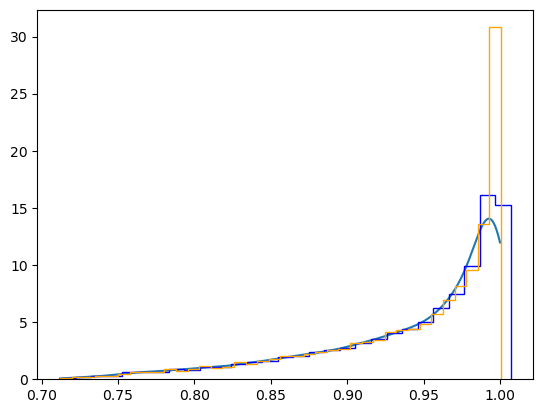

In [4]:
y = np.linspace(min(f), max(f), N)

def kde_sklearn(data, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(y[:, np.newaxis])

    return np.exp(log_pdf)

PDFtophat = kde_sklearn(f, bandwidth=0.01, kernel="gaussian")
plt.plot(y, PDFtophat)
hist(f, bins="scott", histtype="step", density=True, color='blue')
hist(f, bins="freedman", histtype="step", density=True, color='orange')

In [7]:
D_m = []
D_f = []

i = 0
for i in range(0, N):
    D_m.append(abs(M_irr[i]-mass[i]))
    D_f.append(abs(M_irr[i]-f[i]))
    
D_m = np.array(D_m)
D_f = np.array(D_f)
print(max(D_m))
print(max(D_f))

0.29256646974396716
0.06767057501546503


Let's now vary the value of $\sigma$ and compute the KS distance between $M_{irr}$ and $f$ and between $M_{irr}$ and $M$.

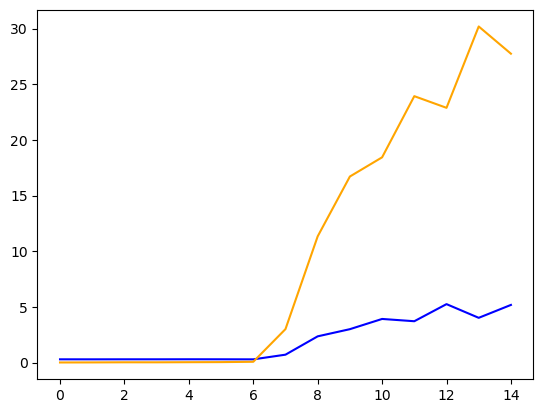

In [13]:
k = 0
n = 1000

f_sigma = np.copy(f)  # in fact f doesn't depend on the mass
D_max_m = []
D_max_f = []
sigma = [0.001, 0.003, 0.006, 0.007, 0.01, 0.012, 0.016, 1, 3.9, 4.6, 5.7, 6.8, 7.1, 8.3, 9.4]

for k in sigma:
    mass_sigma = []
    distG = scipy.stats.norm(loc=1, scale=k)
    mass_sigma = distG.rvs(N)

    M_irr_sigma = []

    i = 0
    for i in range(0, n): 
        M_irr_sigma.append(mass_sigma[i]*math.sqrt((1+math.sqrt(1-spin[i]**2))/2))

    M_irr_sigma = np.array(M_irr_sigma)

    PDFtophat = kde_sklearn(M_irr_sigma, bandwidth=0.01, kernel="gaussian")
    PDFtophat = kde_sklearn(f_sigma, bandwidth=0.01, kernel="gaussian")

    D_sigma_m = []
    D_sigma_f = []
    j = 0
    for j in range(0, n):
        D_sigma_m.append(abs(M_irr_sigma[j]-mass_sigma[j]))
        D_sigma_f.append(abs(M_irr_sigma[j]-f_sigma[j]))

    D_sigma_m = np.array(D_sigma_m)
    D_sigma_f = np.array(D_sigma_f)
    D_max_m.append(max(D_sigma_m))
    D_max_f.append(max(D_sigma_f))
    
D_max_m = np.array(D_max_m)
D_max_f = np.array(D_max_f)
plt.plot(D_max_m, color='blue')
plt.plot(D_max_f, color='orange')

As I can see, the more $\sigma$ increases the more the KS distance between $M_{irr}$ and the mass (blue line) and the KS distance between $M_{irr}$ and $f$ (orange line) increases: in fact, in the generation of the masses from the Gaussian distribution the more I increase $\sigma$ the more I can have values of the mass different from the mean value $\mu$, the more the KS distance increases.